<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/PME_6_MEDIDAS_CORRECTIVAS_PARA_VIOLACI%C3%93N_DE_SUPUESTOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# CARGA DE DATOS
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Variables de interés según práctica
vars_practica = ['medv', 'rm', 'lstat', 'tax', 'rad', 'ptratio']
df_practica = df[vars_practica].copy()
df_practica.rename(columns={'medv': 'MEDV'}, inplace=True)

print(f"Observaciones: {df_practica.shape[0]}, Variables: {df_practica.shape[1]}")
print(df_practica.head())

Observaciones: 506, Variables: 6
   MEDV     rm  lstat  tax  rad  ptratio
0  24.0  6.575   4.98  296    1     15.3
1  21.6  6.421   9.14  242    2     17.8
2  34.7  7.185   4.03  242    2     17.8
3  33.4  6.998   2.94  222    3     18.7
4  36.2  7.147   5.33  222    3     18.7


         MEDV      rm   lstat     tax     rad  ptratio
count  506.00  506.00  506.00  506.00  506.00   506.00
mean    22.53    6.28   12.65  408.24    9.55    18.46
std      9.20    0.70    7.14  168.54    8.71     2.16
min      5.00    3.56    1.73  187.00    1.00    12.60
25%     17.02    5.89    6.95  279.00    4.00    17.40
50%     21.20    6.21   11.36  330.00    5.00    19.05
75%     25.00    6.62   16.96  666.00   24.00    20.20
max     50.00    8.78   37.97  711.00   24.00    22.00


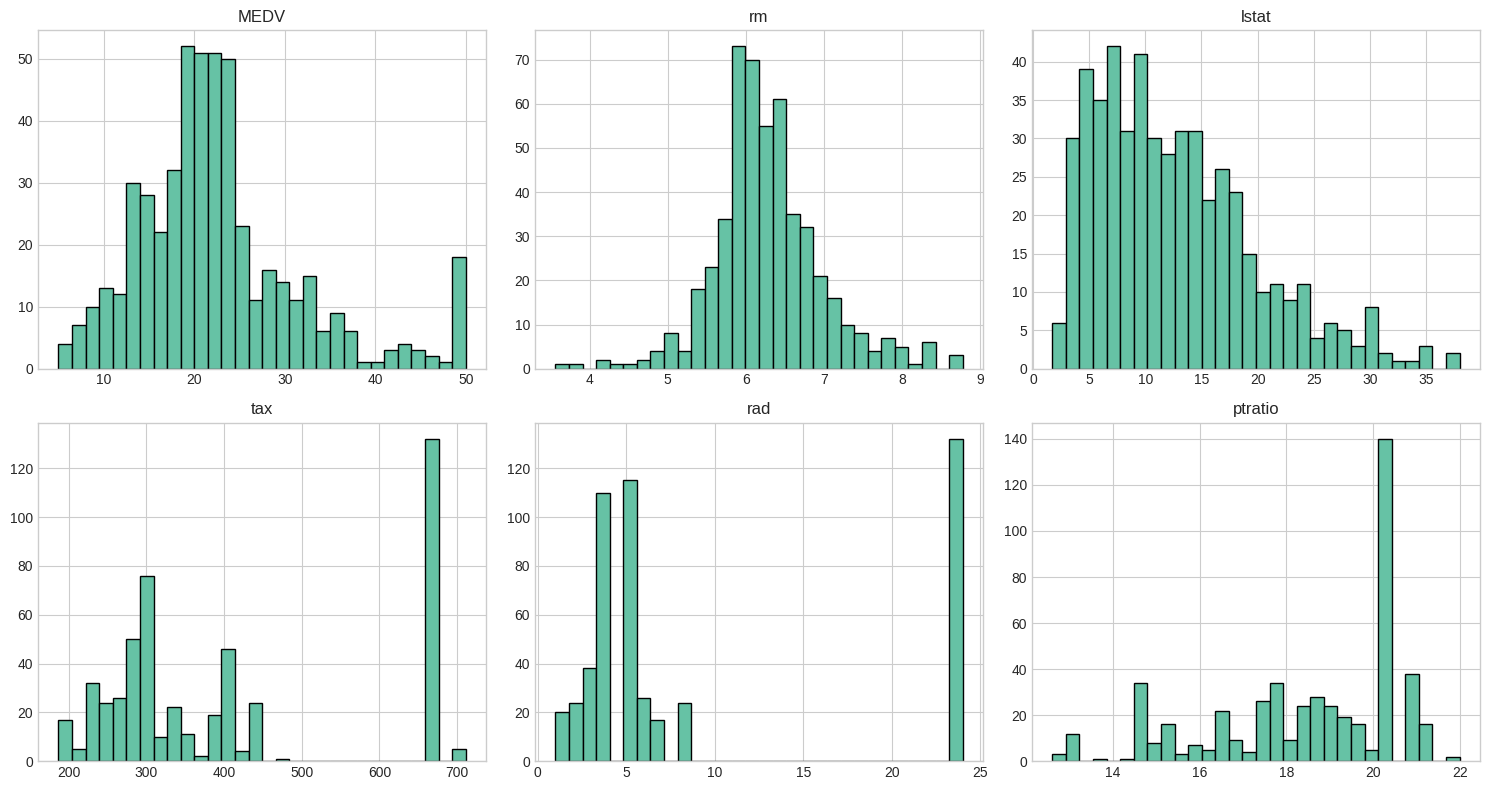

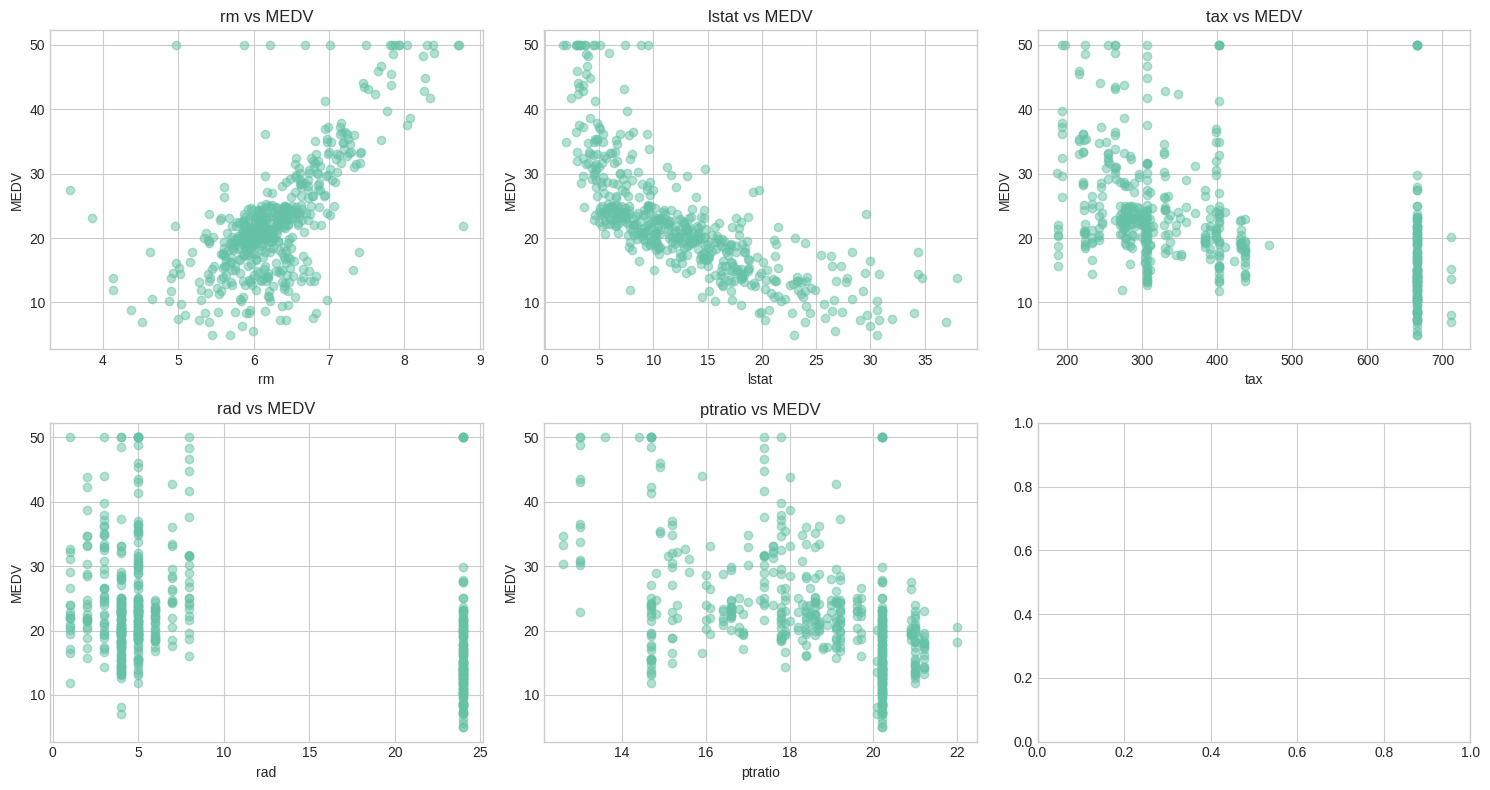

In [ ]:

# Estadísticas descriptivas
print(df_practica.describe().round(2))

# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(df_practica.columns):
    axes[i].hist(df_practica[col], bins=30, edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

# Scatter plots vs MEDV
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate([c for c in df_practica.columns if c != 'MEDV']):
    axes[i].scatter(df_practica[col], df_practica['MEDV'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{col} vs MEDV')
plt.tight_layout()
plt.show()

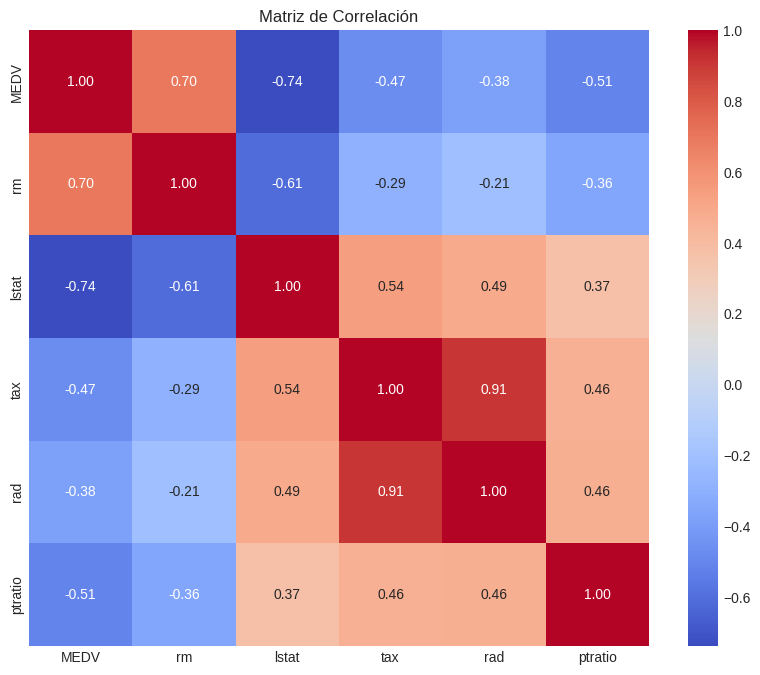

Correlación TAX-RAD: 0.91

VIF por variable:
  Variable     VIF
0    const  337.19
1       rm    1.74
2    lstat    2.11
3      tax    6.39
4      rad    6.15
5  ptratio    1.40


In [ ]:
# Matriz de correlación
corr_matrix = df_practica.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

print("Correlación TAX-RAD:", corr_matrix.loc['tax', 'rad'].round(3))

# Cálculo de VIF
X = df_practica.drop('MEDV', axis=1)
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]
vif_data["VIF"] = vif_data["VIF"].round(2)
print("\nVIF por variable:")
print(vif_data)

# Corrección: eliminar RAD (menor relevancia teórica que TAX)
X_corr = df_practica.drop(['MEDV', 'rad'], axis=1)
X_corr_const = sm.add_constant(X_corr)

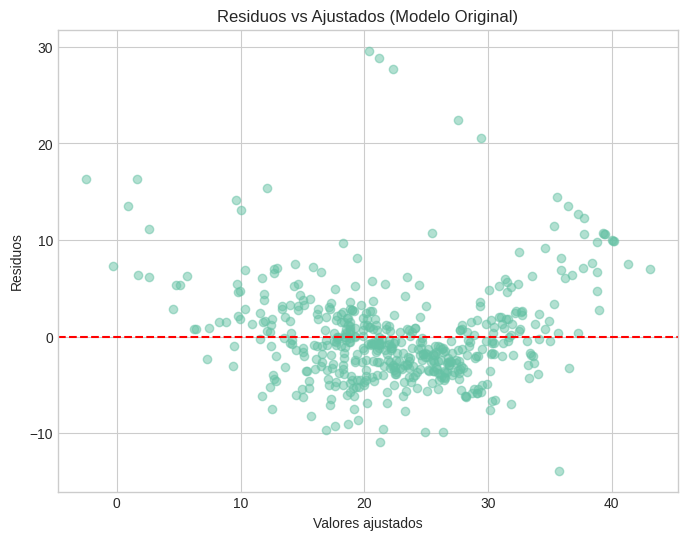


Prueba Breusch-Pagan:
LM Stat: 40.615, p-value: 0.0000


In [ ]:
# Modelo original
y = df_practica['MEDV']
X_orig = sm.add_constant(df_practica.drop('MEDV', axis=1))
model_orig = sm.OLS(y, X_orig).fit()

# Residuos vs ajustados
fitted_orig = model_orig.fittedvalues
resid_orig = model_orig.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted_orig, resid_orig, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Ajustados (Modelo Original)')
plt.show()

# Prueba de Breusch-Pagan
bp_test = het_breuschpagan(resid_orig, X_orig)
labels = ['LM Statistic', 'LM p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))
print("\nPrueba Breusch-Pagan:")
print(f"LM Stat: {bp_results['LM Statistic']:.3f}, p-value: {bp_results['LM p-value']:.4f}")

# Corrección 1: Transformación logarítmica en MEDV
df_practica['log_MEDV'] = np.log(df_practica['MEDV'])
y_log = df_practica['log_MEDV']
X_log = sm.add_constant(df_practica.drop(['MEDV', 'rad'], axis=1))  # sin RAD
model_log = sm.OLS(y_log, X_log).fit()

# Corrección 2: Errores estándar robustos (HC1)
model_robust = model_orig.get_robustcov_results(cov_type='HC1')

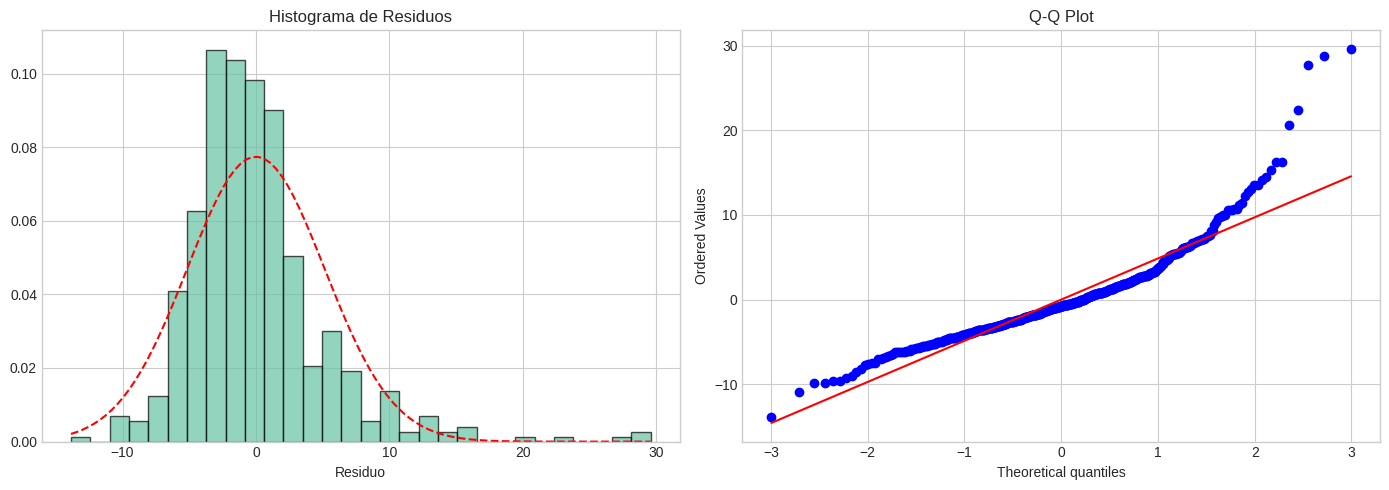


Jarque-Bera: stat=1110.137, p-value=0.0000


In [ ]:
# Histograma + Q-Q plot para modelo original
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con densidad
axes[0].hist(resid_orig, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(resid_orig.min(), resid_orig.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, resid_orig.mean(), resid_orig.std()), 'r--')
axes[0].set_title('Histograma de Residuos')
axes[0].set_xlabel('Residuo')

# Q-Q plot
stats.probplot(resid_orig, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Prueba de normalidad (Jarque-Bera)
jb_test = stats.jarque_bera(resid_orig)
print(f"\nJarque-Bera: stat={jb_test[0]:.3f}, p-value={jb_test[1]:.4f}")

# Corrección: transformación log ya aplicada; outliers pueden eliminarse si es necesario

In [ ]:
# Modelo 1: Original
print("=== MODELO ORIGINAL ===")
print(model_orig.summary().tables[1])

# Modelo 2: Sin multicolinealidad (sin RAD)
X_no_rad = sm.add_constant(df_practica.drop(['MEDV', 'rad'], axis=1))
model_no_rad = sm.OLS(y, X_no_rad).fit()
print("\n=== MODELO SIN RAD ===")
print(model_no_rad.summary().tables[1])

# Modelo 3: Log(MEDV)
print("\n=== MODELO LOG(MEDV) ===")
print(model_log.summary().tables[1])

# Modelo 4: Errores robustos
print("\n=== MODELO CON ERRORES ROBUSTOS (HC1) ===")
print(model_robust.summary().tables[1])

# Comparación de R² ajustado y AIC
comparacion = pd.DataFrame({
    'Modelo': ['Original', 'Sin RAD', 'Log(MEDV)', 'Robusto'],
    'R² ajustado': [
        model_orig.rsquared_adj,
        model_no_rad.rsquared_adj,
        model_log.rsquared_adj,
        model_orig.rsquared_adj  # mismo ajuste, SE distintos
    ],
    'AIC': [
        model_orig.aic,
        model_no_rad.aic,
        model_log.aic,
        model_orig.aic
    ]
})
print("\n=== COMPARACIÓN RESUMEN ===")
print(comparacion.round(3))

=== MODELO ORIGINAL ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5259      4.229      5.327      0.000      14.218      30.834
rm             4.3260      0.433      9.982      0.000       3.475       5.177
lstat         -0.5558      0.047    -11.867      0.000      -0.648      -0.464
tax           -0.0116      0.003     -3.368      0.001      -0.018      -0.005
rad            0.2068      0.066      3.149      0.002       0.078       0.336
ptratio       -0.9411      0.126     -7.467      0.000      -1.189      -0.693

=== MODELO SIN RAD ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -56.2477      2.480    -22.684      0.000     -61.119     -51.376
rm             2.1249      0.204     10.430      0.000       1.725       2.525
lsta